In [1]:
import numpy as np, basic, cosmology, local, tools_multitracer as mass, plottools as pl
from matplotlib.pyplot import *

In [2]:
lmax = 1024
euc_zbin = 5
lss_zbin = 5

In [3]:
frac = mass.galaxy_distribution(np.linspace(0,50,1000),zbn={'euc':euc_zbin,'lss':lss_zbin})[3]

In [4]:
l, camb_cls = mass.read_camb_cls(add_euc=euc_zbin,add_lss=lss_zbin,lmax=lmax)

In [5]:
# for cross spectrum
vecs = {}
ocov = {}
Scov = mass.get_covariance_signal(lmax,add_cmb=['klb'],add_euc=euc_zbin,add_lss=lss_zbin)
print(np.shape(Scov))

(12, 12, 1025)


In [6]:
# CIB covariance
scib = mass.get_covariance_signal(lmax,add_cmb=[],add_euc=0,add_lss=0)
ncib = mass.get_covariance_noise(lmax,add_cmb=[],add_euc=0,add_lss=0)
vecs['cib'] = Scov[0,1:2,:]
ocov['cib'] = scib + ncib

In [7]:
# Euclid covariance
seuc = mass.get_covariance_signal(lmax,add_cmb=[],add_cib=False,add_euc=euc_zbin,add_lss=0)
neuc = mass.get_covariance_noise(lmax,frac=frac,add_cmb=[],add_cib=False,add_euc=euc_zbin,add_lss=0)
vecs['euc'] = Scov[0,2:2+euc_zbin,:]
ocov['euc'] = seuc + neuc

In [8]:
# LSST covariance
slss = mass.get_covariance_signal(lmax,add_cmb=[],add_cib=False,add_euc=0,add_lss=lss_zbin)
nlss = mass.get_covariance_noise(lmax,frac=frac,add_cmb=[],add_cib=False,add_euc=0,add_lss=lss_zbin)
vecs['lss'] = Scov[0,2+euc_zbin:2+euc_zbin+lss_zbin,:]
ocov['lss'] = slss + nlss

In [13]:
# gal covariance
sks4 = mass.get_covariance_signal(lmax,add_cmb=['ks4'],add_cib=False,add_euc=0,add_lss=0)
nks4 = mass.get_covariance_noise(lmax,add_cmb=['ks4'],add_cib=False,add_euc=0,add_lss=0)
vecs['ks4'] = Scov[0,0:1,:]
ocov['ks4'] = sks4 + nks4

In [20]:
icov = {}
rho  = {}
for t in ['cib','euc','lss','ks4']:
    icov[t] = ocov[t].copy()
    icov[t][:,:,2:] = np.array( [ np.linalg.inv(ocov[t][:,:,l]) for l in range(2,lmax+1) ] ).T
    rho[t] = np.array( [ np.dot( vecs[t][:,l], np.dot( icov[t][:,:,l], vecs[t][:,l] ) ) for l in range(lmax+1) ] ) / ( camb_cls['klbklb'][:lmax+1] + 1e-30 )

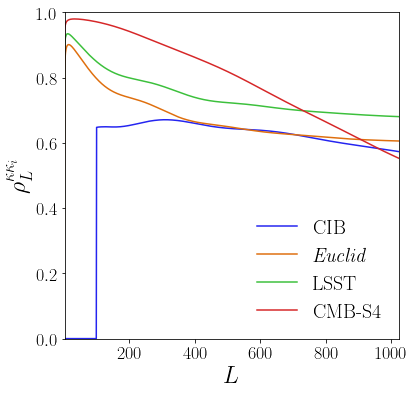

In [27]:
pl.plot_1dstyle(fsize=[6,6],usetex=True,xmin=2,xmax=lmax,ymin=0,ymax=1,xlab=r'$L$',ylab=r'$\rho^{\kappa\kappa_i}_L$',
                xlabsize=24,ylabsize=24,
                xticks_labsize=18,yticks_labsize=18,legend_size=20)
rcParams["font.family"] = "Arial"
for t, label in [('cib','CIB'),('euc',r'{\it Euclid}'),('lss','LSST'),('ks4',r'CMB-S4')]:
    plot(l, np.sqrt(rho[t]),label=label)
legend()
savefig('fig_rho_ext.pdf',bbox_inches = 'tight', pad_inches = 0.1)